# **Predicting Doordash Delivery Duration with Machine Learning**

## ADS-505 Final Team Project
---
**Data source:** Kaggle  
**Team members:** Julia Gonzalez, Caly Nguyen, Aishwarya Kuduvalli

## **Project Objective**
---

The objective of this project is to examine the relationship between order, market, and store-related information, and delivery duration, with the aim of estimating the outcome with predictive modeling. 

With Kaggle’s DoorDash ETA Prediction dataset, the team will perform exploratory data analysis, pre-process the data, develop and compare multiple machine learning models, and select a final model based on performance and potential business impact. The limitations associated with the historical nature of the data, which consists of orders from early 2015, will also be taken into consideration. Results will be presented as an actionable recommendation, determining what contributes to delivery duration and ETA accuracy and how these findings can be used to improve delivery operations and customer experience. 

## **Variables**
---
- `market_id` - City/region the DoorDash order was made (in ID form, from `1` to `6`)
- `created_at` - UTC timestamp of when the order was made
- `actual_delivery_time` - UTC timestamp of when the order was delivered
- `store_id` - Restaurant the order was made to (in ID form)
- `store_primary_category` - Restaurant's cuisine type (e.g. `american`, `mexican`, `NA`)
- `order_protocol` - Method through which order was received (`1` to `7`)
- `total_items` - Total number of items in the order 
- `subtotal` - Order subtotal (in cents)
- `num_distinct_items` - Number of distinct items in the order
- `min_item_price` - Minimum item price in the order (in cents)
- `max_item_price` - Maximum item price in the order (in cents) 
- `total_onshift_dashers` - Total number of dashers within a 10 mile radius of the store during placement 
- `total_busy_dashers` - Subset of `total_onshift_dashers` who were currently busy with an order
- `total_outstanding_orders` - Number of active orders being processed within a 10 mile radius of the current order
- `estimated_order_place_duration` - Estimated time between order placement and restaurant receiving it (in seconds)
- `estimated_store_to_consumer_driving_duration` - Estimated time to drive from store to customer (in seconds) 

## **Imports**
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

## **Data Loading, Initial Exploration, and Cleaning**
---

### Loading the Data

In [2]:
doordash = pd.read_csv("historical_data.csv")

# First 5 rows
doordash.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


### Overview

**Dimensions**

In [3]:
print("Rows and columns:", doordash.shape)

Rows and columns: (197428, 16)


- 197,428 rows
- 16 columns

**Column Names**

In [4]:
columns = doordash.columns

print("Column names:")
for c in columns:
    print(c, end = ", ")

Column names:
market_id, created_at, actual_delivery_time, store_id, store_primary_category, order_protocol, total_items, subtotal, num_distinct_items, min_item_price, max_item_price, total_onshift_dashers, total_busy_dashers, total_outstanding_orders, estimated_order_place_duration, estimated_store_to_consumer_driving_duration, 

**Data Types**

In [5]:
doordash.dtypes

market_id                                       float64
created_at                                          str
actual_delivery_time                                str
store_id                                          int64
store_primary_category                              str
order_protocol                                  float64
total_items                                       int64
subtotal                                          int64
num_distinct_items                                int64
min_item_price                                    int64
max_item_price                                    int64
total_onshift_dashers                           float64
total_busy_dashers                              float64
total_outstanding_orders                        float64
estimated_order_place_duration                    int64
estimated_store_to_consumer_driving_duration    float64
dtype: object

**Descriptive Statistics**

In [6]:
doordash.describe().T

,count,mean,std,min,25%,50%,75%,max
market_id,196441.0,2.978706,1.524867,1.0,2.0,3.0,4.0,6.0
store_id,197428.0,3530.510272,2053.496711,1.0,1686.0,3592.0,5299.0,6987.0
order_protocol,196433.0,2.882352,1.503771,1.0,1.0,3.0,4.0,7.0
total_items,197428.0,3.196391,2.666546,1.0,2.0,3.0,4.0,411.0
subtotal,197428.0,2682.331402,1823.093688,0.0,1400.0,2200.0,3395.0,27100.0
num_distinct_items,197428.0,2.670791,1.630255,1.0,1.0,2.0,3.0,20.0
min_item_price,197428.0,686.218470,522.038648,-86.0,299.0,595.0,949.0,14700.0
max_item_price,197428.0,1159.588630,558.411377,0.0,800.0,1095.0,1395.0,14700.0
total_onshift_dashers,181166.0,44.808093,34.526783,-4.0,17.0,37.0,65.0,171.0
total_busy_dashers,181166.0,41.739747,32.145733,-5.0,15.0,34.0,62.0,154.0


### Missing and Duplicate Values

**Duplicated Row Counts**

In [7]:
duplicated = doordash.duplicated().sum()
print("Duplicated row counts:", duplicated)

Duplicated row counts: 0


**Missing Value Counts**

In [8]:
nulls = doordash.isnull().sum()
SAMPLESIZE = 197428

# Table of null values
nulltable = pd.DataFrame({"Count": nulls,
                          "Percentage": round(nulls / SAMPLESIZE * 100, 3)})
nulltable

,Count,Percentage
market_id,987,0.500
created_at,0,0.000
actual_delivery_time,7,0.004
store_id,0,0.000
store_primary_category,4760,2.411
order_protocol,995,0.504
total_items,0,0.000
subtotal,0,0.000
num_distinct_items,0,0.000
min_item_price,0,0.000


There were missing values identified in `market_id`, `store_primary_category`, `order_protocol`, `total_onshift_dashers`, `total_busy_dashers`, `total_outstanding_orders`, and `estimated_store_to_consumer_driving_duration`. Handling would require either imputation, representing missingness in some form, or deleting rows. 

`total_onshift_dashers`, `total_busy_dashers`, and `total_outstanding_orders` all had the same higher number of missing values of 16,262. Their relationship with each other and the remaining variables was considered further, using contingency tables:

In [9]:
# Total onshift dashers and total busy dashers
pd.crosstab(doordash["total_onshift_dashers"]
            .isnull(),
            doordash["total_busy_dashers"]
            .isnull())

total_busy_dashers,False,True
total_onshift_dashers,,
False,181166,0
True,0,16262


In [10]:
# Total onshift dashers and total outstanding orders
round(pd.crosstab(doordash["total_onshift_dashers"]
                  .isnull(),
                  doordash["total_outstanding_orders"]
                  .isnull()), 3)

total_outstanding_orders,False,True
total_onshift_dashers,,
False,181166,0
True,0,16262


In [11]:
# Total busy dashers and total outstanding orders
round(pd.crosstab(doordash["total_busy_dashers"]
                  .isnull(),
             doordash["total_outstanding_orders"]
                  .isnull()), 3)

total_outstanding_orders,False,True
total_busy_dashers,,
False,181166,0
True,0,16262


Neither of these three variables contain missing values independently of one another; missingness in one indicated missingness for the remaining 2. Next, the relationship between the three and `market_id` and `order_protocol` was examined, using using `total_onshift_dashers` to compare. These variables were selected because of their categorical nature and easily identifiable categories.

In [12]:
# Three-variable missing values
three_missing = doordash["total_onshift_dashers"].isnull()
three_missing.name = "three_missing"

# Missing value relationship with market_id
round(pd.crosstab(doordash["market_id"],
                  three_missing,
                  normalize = "index"), 3)

three_missing,False,True
market_id,,
1.0,0.995,0.005
2.0,0.995,0.005
3.0,0.930,0.070
4.0,0.995,0.005
5.0,0.995,0.005
6.0,0.045,0.955


In [13]:
# Missing value relationship with order_protocol
round(pd.crosstab(doordash["order_protocol"],
                  three_missing,
                  normalize = "index"), 3)

three_missing,False,True
order_protocol,,
1.0,0.924,0.076
2.0,0.888,0.112
3.0,0.903,0.097
4.0,0.910,0.090
5.0,0.948,0.052
6.0,0.860,0.140
7.0,1.000,0.000


From these contingency tables, a strong potential relationship between the three variables' missing values and `market_id` became apparent; market `6` had a substantially larger proportion (95.46%) than all other market types. This suggested that missingness among these variables was not random, but correlated with market. 

**Handling Missing Values**

In [14]:
# Dropping rows with missing actual delivery times
doordash = doordash.dropna(subset = ["actual_delivery_time"])

In [15]:
doordash.isnull().sum()

market_id                                         987
created_at                                          0
actual_delivery_time                                0
store_id                                            0
store_primary_category                           4760
order_protocol                                    995
total_items                                         0
subtotal                                            0
num_distinct_items                                  0
min_item_price                                      0
max_item_price                                      0
total_onshift_dashers                           16262
total_busy_dashers                              16262
total_outstanding_orders                        16262
estimated_order_place_duration                      0
estimated_store_to_consumer_driving_duration      526
dtype: int64

The 7 missing values in `actual_delivery_time` were addressed by dropping the corresponding rows; the loss was minimum and they could not be used to calculate delivery duration. 

Imputation to handle missing values would be performed post-partition to prevent data leakage. The variables `market_id`, `store_primary_category`, and `order_protocol`, all containing missing values, were slated for mode imputation. The three variables with the same number of missing values, `total_onshift_dashers`, `total_outstanding_orders`, and `total_busy_dashers`, were slated for median imputation rather than removing the observations to prevent a 8.2% loss of the dataset, and due to the skew. Median imputation was also considered appropriate for `estimated_store_to_consumer_driving_duration`.

### Outliers and Impossible Values

**Outliers**

In [16]:
# Numeric variables
numeric = ["total_items",
           "subtotal",
           "num_distinct_items",
           "min_item_price",
           "max_item_price",
           "total_onshift_dashers",
           "total_busy_dashers",
           "total_outstanding_orders",
           "estimated_order_place_duration",
           "estimated_store_to_consumer_driving_duration"]

In [17]:
# Checking skew
round(doordash[numeric].skew(), 3)

total_items                                     21.414
subtotal                                         1.962
num_distinct_items                               1.592
min_item_price                                   2.331
max_item_price                                   2.201
total_onshift_dashers                            0.861
total_busy_dashers                               0.783
total_outstanding_orders                         1.195
estimated_order_place_duration                   1.144
estimated_store_to_consumer_driving_duration     0.148
dtype: float64

In [18]:
# Checking total_items
doordash["total_items"].sort_values(ascending = False).head(10)

47231     411
182223     84
182800     66
182796     64
75577      59
15053      57
11055      56
105348     51
52211      50
106098     50
Name: total_items, dtype: int64

In [19]:
# Anomalous row
doordash.loc[47231]

market_id                                                       2.0
created_at                                      2015-02-06 00:42:39
actual_delivery_time                            2015-02-06 01:33:34
store_id                                                        777
store_primary_category                                         fast
order_protocol                                                  4.0
total_items                                                     411
subtotal                                                       3115
num_distinct_items                                                5
min_item_price                                                    0
max_item_price                                                  299
total_onshift_dashers                                          35.0
total_busy_dashers                                             35.0
total_outstanding_orders                                       39.0
estimated_order_place_duration                  

In [20]:
# Average price per item
3115 / 411

7.579075425790754

In [21]:
# Dropping anomalous row
doordash = doordash.drop(index = 47231)

In [22]:
# New total_items skew
print(round(doordash["total_items"].skew(), 3))

3.985


Using `skew` to check for outliers, `total_items` was found to be highly right skewed at 21.414. Its top 10 values were identified; on its own, a high number of items did not seem unusual, as large orders are possible. However, the maximum value of 411 was significantly higher than the next highest. Further examination of the corresponding row revealed that the order had a subtotal of ＄31.15, making the average price of each item only ＄0.08. Given these inconsistencies, this record was considered potentially invalid and removed, considerably reducing the column's skew. 

**Negative Values**

In [23]:
# Checking for negative values in each column
print("Negative values")
for n in numeric:
    negatives = (doordash[n] < 0).sum()
    
    if negatives > 0:
        print(n + ":", negatives)

# Removing rows with negative values
for n in numeric:
    doordash = doordash[doordash[n] >= 0]

Negative values
min_item_price: 13
total_onshift_dashers: 21
total_busy_dashers: 21
total_outstanding_orders: 44


There were negative, and therefore impossible, values found in `min_item_price`, `total_onshift_dashers`, `total_busy_dashers`, and `total_outstanding_orders`. In response, these rows were also dropped.

## **Feature Engineering / Extraction**
---

### Creating the Response Variable

In [24]:
# Datetime conversion
doordash["created_at"] = pd.to_datetime(doordash["created_at"])
doordash["actual_delivery_time"] = pd.to_datetime(doordash["actual_delivery_time"])

**Response Variable - Delivery Duration**

In [25]:
# Delivery duration (minutes)
doordash["delivery_duration"] = (doordash["actual_delivery_time"]
                                 - doordash["created_at"]).dt.total_seconds() / 60
doordash["delivery_duration"].describe()

count    180584.000000
mean         47.779945
std          27.483762
min           1.683333
25%          35.083333
50%          44.366667
75%          56.383333
max        6231.316667
Name: delivery_duration, dtype: float64

The response variable `delivery_duration` was created by subtracting `created_at` from `actual_delivery_time` (both of which were previously converted to `datetime` format) and calculating the resulting duration in minutes. 

**Delivery Duration Outliers**

In [26]:
# Number of delivery durations above 5 hours
abovefive = (doordash["delivery_duration"] > 300).sum()

print("Number of delivery durations above 5 hours:", abovefive)

Number of delivery durations above 5 hours: 31


In [27]:
# Removing rows with delivery duration > 5 hours
doordash = doordash[doordash["delivery_duration"] <= 300]

Outliers in `delivery_duration` were defined as values above 5 hours (300 minutes). 31 records were found to exceed this threshold and were therefore removed.

### Time Variables

**Extracting Time-Related Variables**

In [28]:
# Hour the order was made
doordash["order_hour"] = doordash["created_at"].dt.hour

# Day of week the order was made
doordash["order_dayofweek"] = doordash["created_at"].dt.dayofweek

# Whether the order was made on a weekend or not
doordash["order_weekend"] = (doordash["created_at"].dt.dayofweek >= 5).astype(int)

**Dropping Original Time Variables**

In [29]:
doordash = doordash.drop(columns = ["created_at",
                                    "actual_delivery_time"])

The variables `order_hour`, `order_dayofweek`, and `order_weekend` signifying the hour the order was made, day of week the order was made, and whether the order was made on a weekend or not were derived from `created_at`. Next, the original time variables were dropped as their necessary information had been distracted and retaining `actual_delivery_time` would result in data leakage.

### Creating Other Variables

In [30]:
# Average quantity ordered of each item
doordash["average_quantity_per_item"] = (doordash["total_items"]
                                         / doordash["num_distinct_items"])

The variables `average_item_price` and `average_quantity_per_item` were also created to potentially provide more information to the analysis regarding the orders. 

### Variable Reorganization

In [31]:
doordash = doordash[["delivery_duration",
                     "market_id",
                     "store_id",
                     "store_primary_category",
                     "order_hour",
                     "order_dayofweek",
                     "order_weekend",
                     "order_protocol",
                     "total_items",
                     "subtotal",
                     "min_item_price",
                     "max_item_price",
                     "num_distinct_items",
                     "average_quantity_per_item",
                     "total_onshift_dashers",
                     "total_busy_dashers",
                     "total_outstanding_orders",
                     "estimated_order_place_duration",
                     "estimated_store_to_consumer_driving_duration"]]
doordash.head()

,delivery_duration,market_id,store_id,store_primary_category,order_hour,order_dayofweek,order_weekend,order_protocol,total_items,subtotal,min_item_price,max_item_price,num_distinct_items,average_quantity_per_item,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,62.983333,1.0,1845,american,22,4,0,1.0,4,3441,557,1239,4,1.0,33.0,14.0,21.0,446,861.0
1,67.066667,2.0,5477,mexican,21,1,0,2.0,1,1900,1400,1400,1,1.0,1.0,2.0,2.0,446,690.0
2,29.683333,3.0,5477,NaN,20,3,0,1.0,1,1900,1900,1900,1,1.0,1.0,0.0,0.0,446,690.0
3,51.250000,3.0,5477,NaN,21,1,0,1.0,6,6900,600,1800,5,1.2,1.0,1.0,2.0,446,289.0
4,39.833333,3.0,5477,NaN,2,6,1,1.0,3,3900,1100,1600,3,1.0,6.0,6.0,9.0,446,650.0


## **Exploratory Data Analysis (EDA)**
---

### Distribution of Delivery Duration

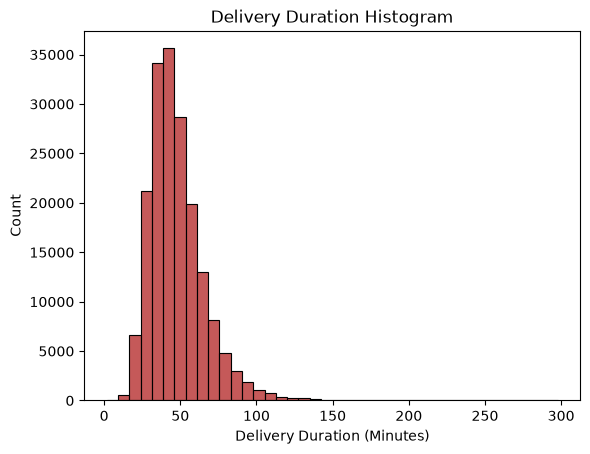

In [32]:
# Histogram of delivery duration

sns.histplot(doordash,
             x = "delivery_duration",
             bins = 40,
             color = "firebrick")

plt.xlabel("Delivery Duration (Minutes)")
plt.ylabel("Count")
plt.title("Delivery Duration Histogram")
plt.show()

### Numeric Variables

**Histograms**

In [33]:
# Remaining numeric variables
numeric = ["total_items",
           "subtotal",
           "min_item_price",
           "max_item_price",
           "num_distinct_items",
           "average_quantity_per_item",
           "total_onshift_dashers",
           "total_busy_dashers",
           "total_outstanding_orders",
           "estimated_order_place_duration",
           "estimated_store_to_consumer_driving_duration"]

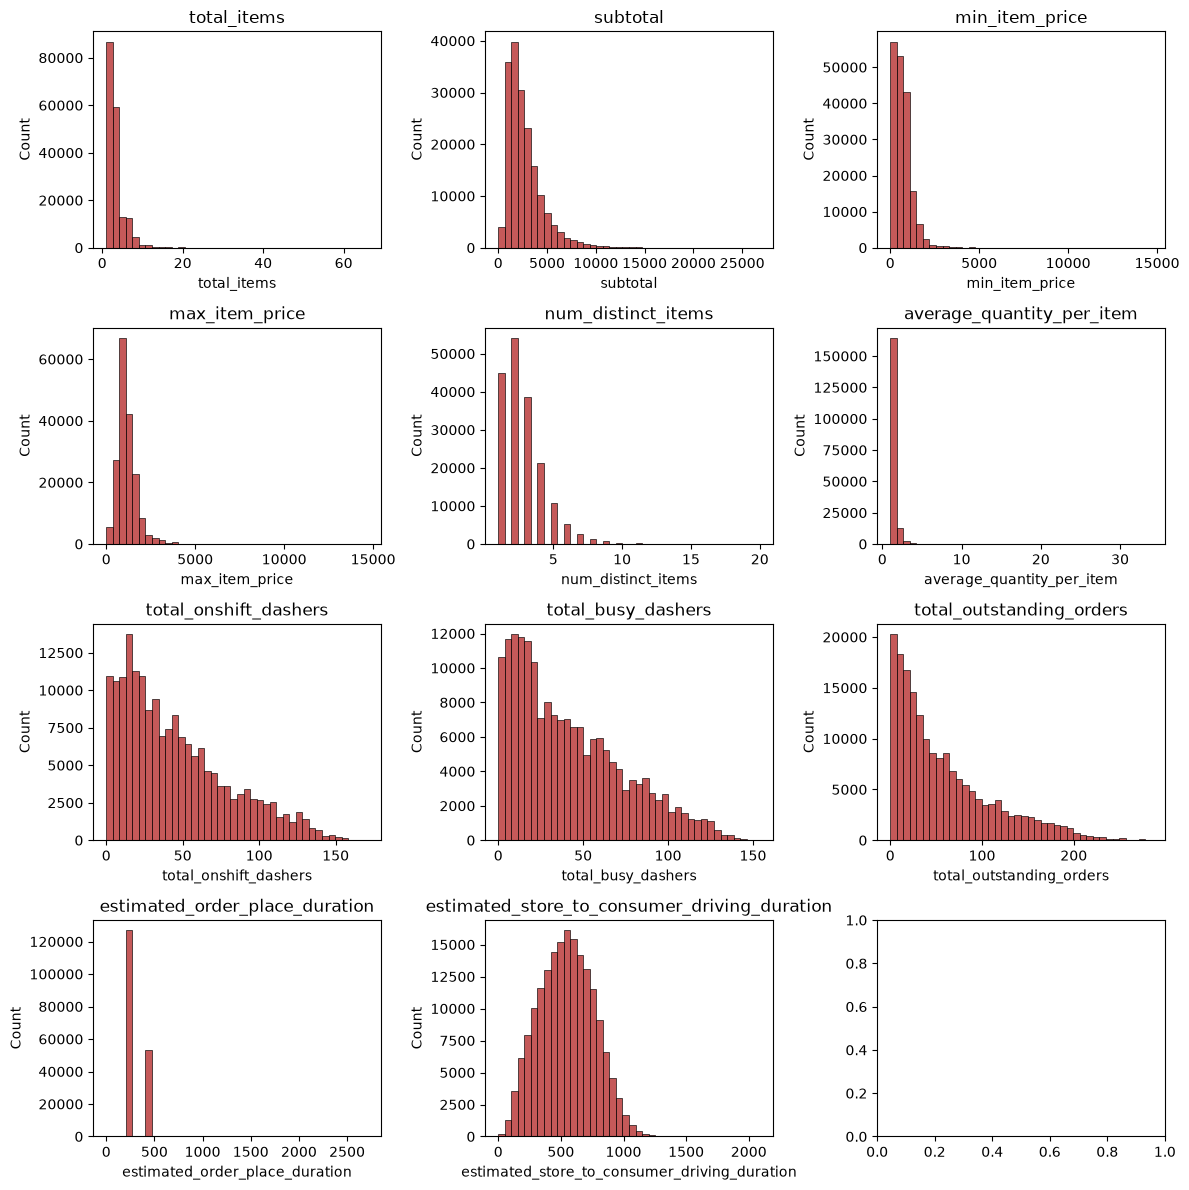

In [34]:
# Numeric variable histograms
fig, axes = plt.subplots(4, 3,
                         figsize = (12, 12))
axes = axes.flatten()

for i, c in enumerate(numeric):
    sns.histplot(doordash[c],
                 bins = 40,
                 ax = axes[i],
                 color = "firebrick")
    axes[i].set_title(c)

plt.tight_layout()
plt.show()

**Bivariate Plots**

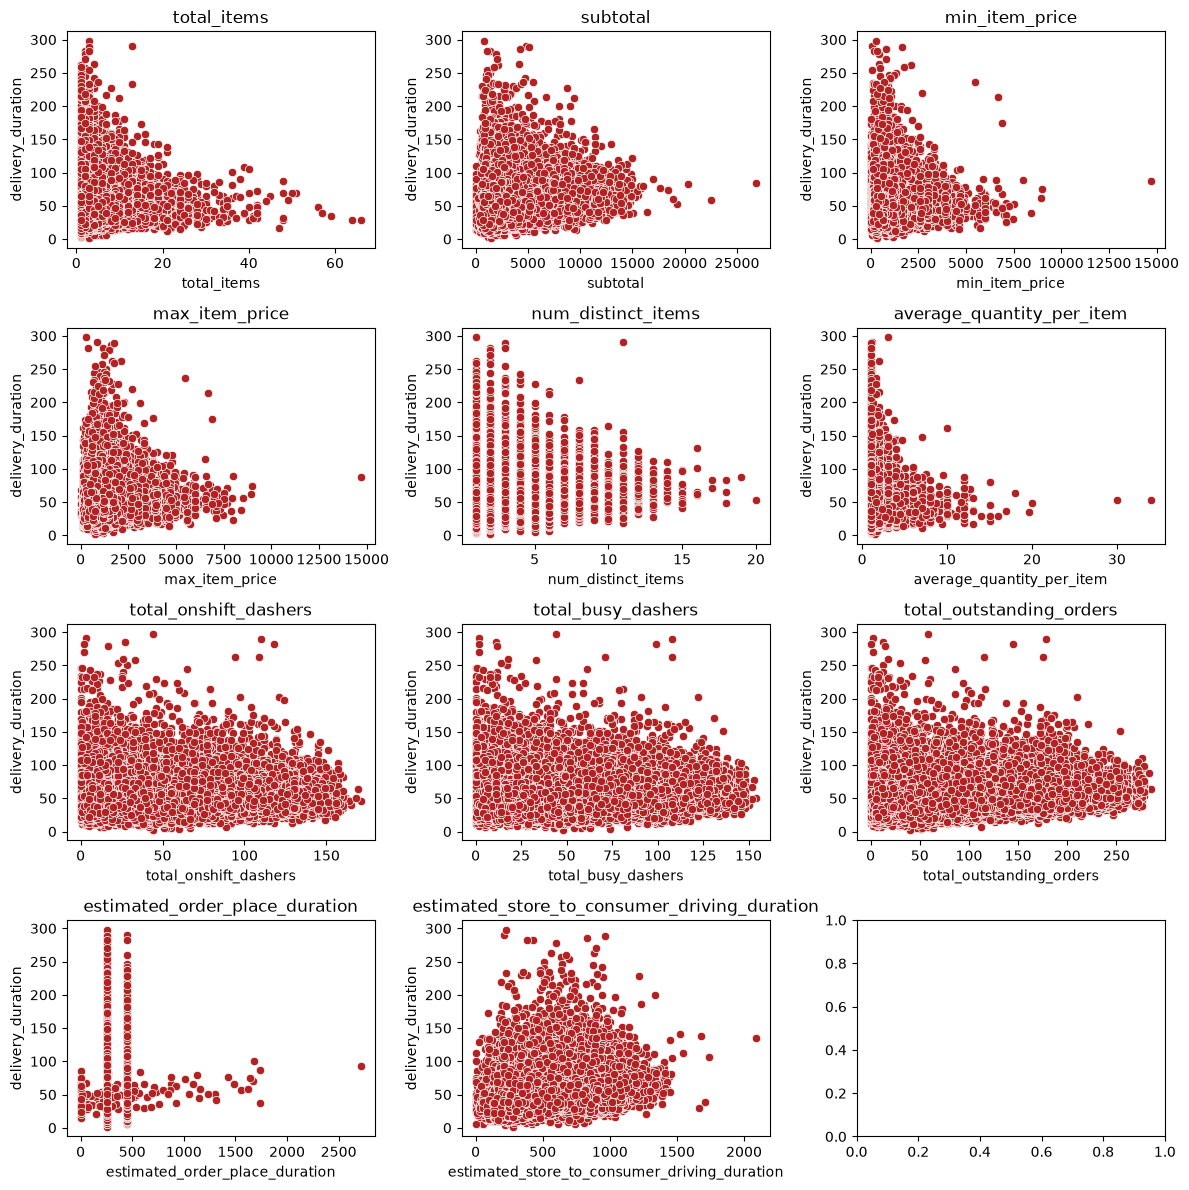

In [35]:
fig, axes = plt.subplots(4, 3, figsize = (12, 12))
axes = axes.flatten()

for i, c in enumerate(numeric):
    sns.scatterplot(data = doordash,
                    x = c,
                    y = "delivery_duration",
                    ax = axes[i],
                    color = "firebrick")
    axes[i].set_title(c)

plt.tight_layout()
plt.show()

### Categorical Variables

**Bar Plots**

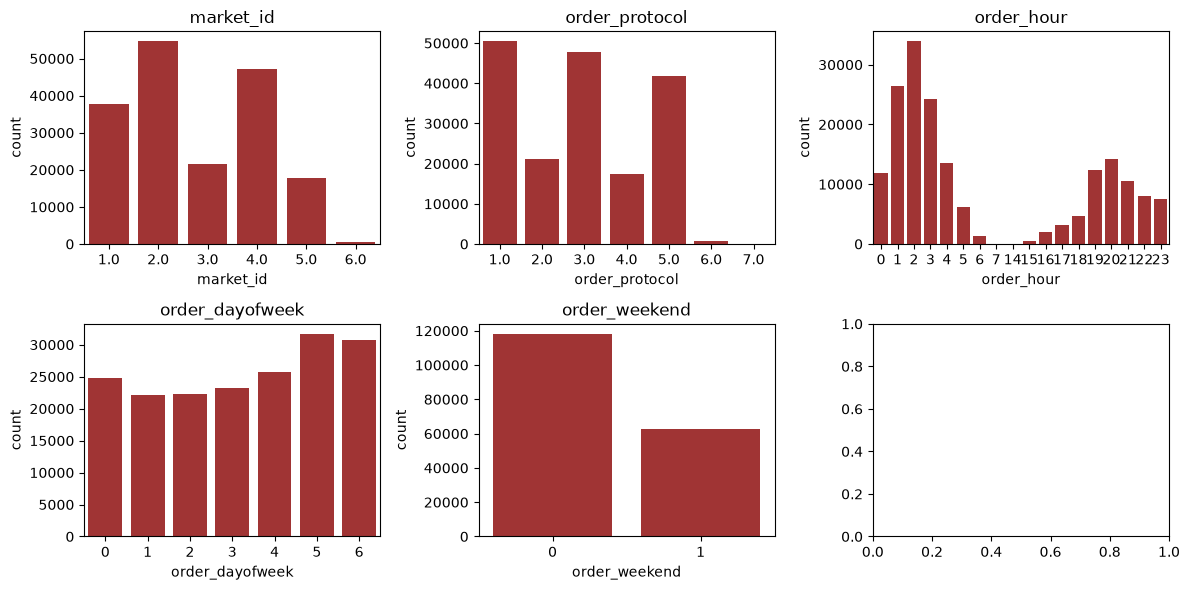

In [36]:
# Categorical variables besides store_primary_category and store_id
categorical = ["market_id",
               "order_protocol",
               "order_hour",
               "order_dayofweek",
               "order_weekend"]

fig, axes = plt.subplots(2, 3,
                         figsize = (12, 6))
axes = axes.flatten()

for i, c in enumerate(categorical):
    sns.countplot(data = doordash,
                  x = c,
                  ax = axes[i],
                  color = "firebrick")
    axes[i].set_title(c)

plt.tight_layout()
plt.show()

**Boxplots**

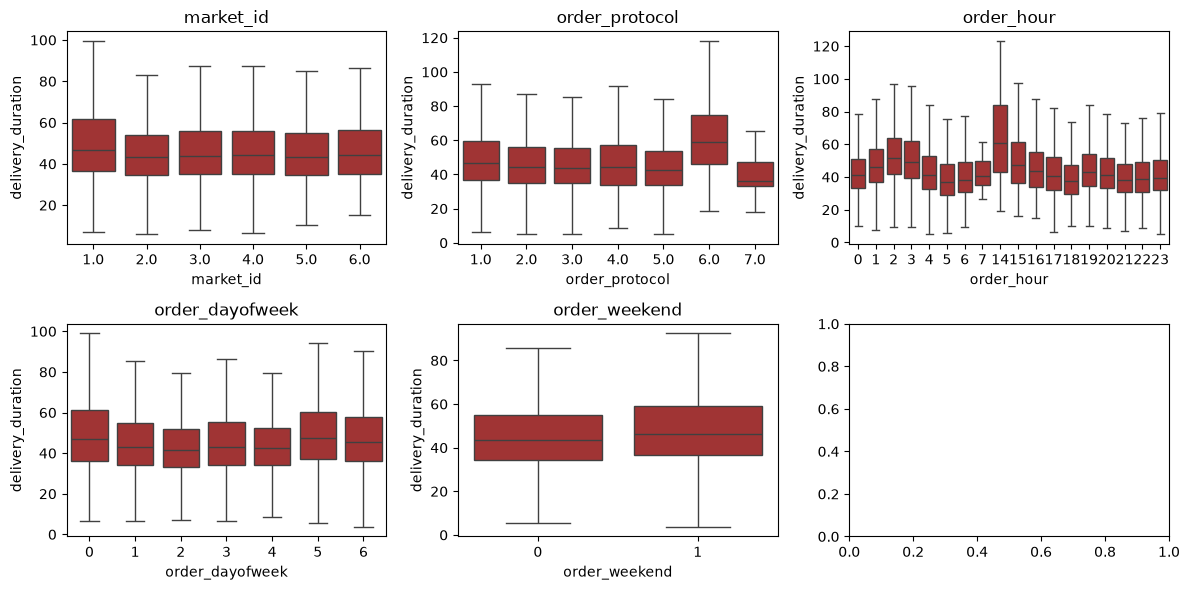

In [37]:
fig, axes = plt.subplots(2, 3,
                         figsize = (12, 6))
axes = axes.flatten()

for i, c in enumerate(categorical):
    sns.boxplot(data = doordash,
                x = c,
                y = "delivery_duration",
                ax = axes[i],
                color = "firebrick",
                showfliers = False)
    axes[i].set_title(c)

plt.tight_layout()
plt.show()

### Correlation Heatmap

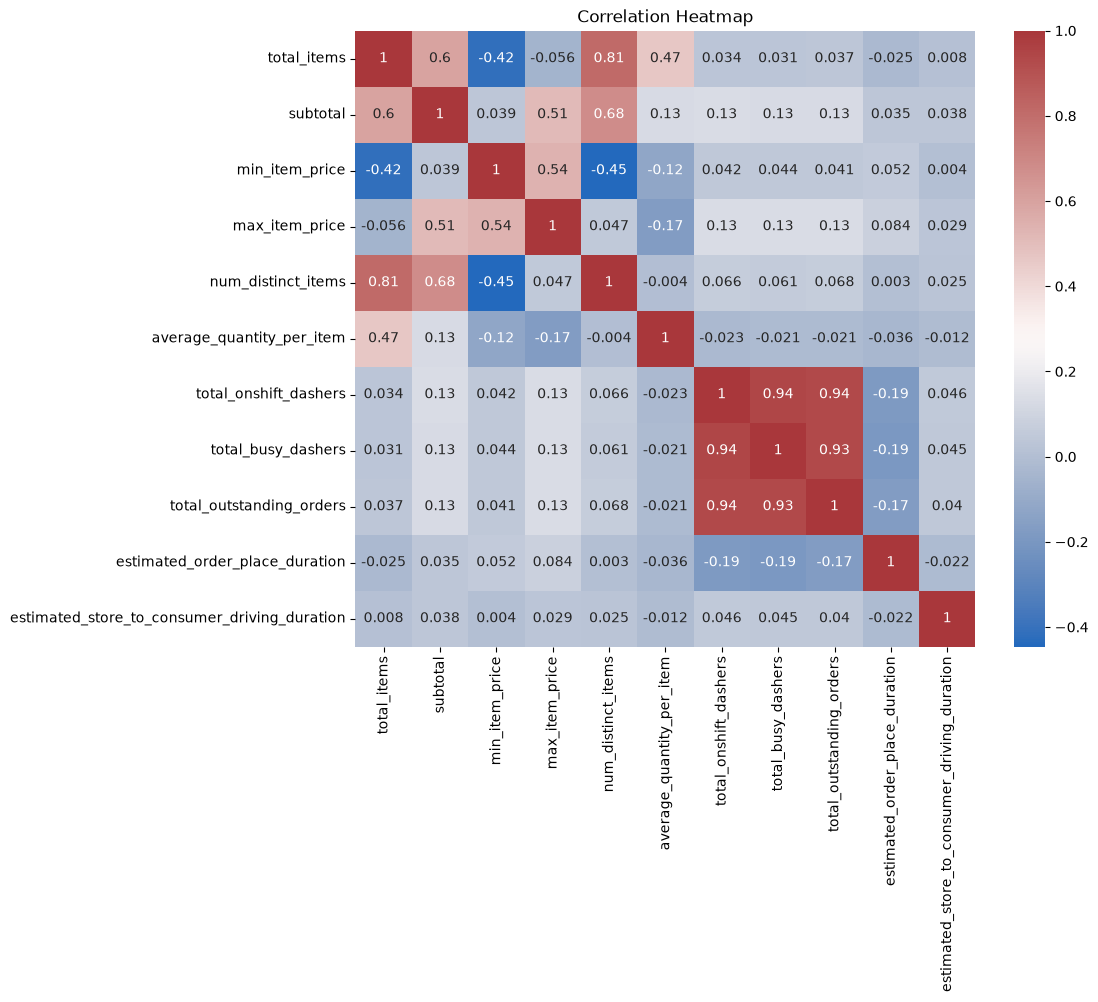

In [38]:
correlations = doordash[numeric].corr().round(3)

plt.figure(figsize = (10, 8))
sns.heatmap(correlations,
            annot = True,
            cmap = "vlag")

plt.title("Correlation Heatmap")
plt.show()

High correlations:
- `total_onshift_dashers` with `total_busy_dashers` (r = 0.94)
- `total_onshift_dashers` with `total_outstanding_orders` (r = 0.94)
- `total_busy_dashers` with `total_outstanding_orders` (r = 0.93)
- `total_items` with `num_distinct_items`: 0.81 (r = 0.81)

Each of these variables represents distinct information that might be relevant to delivery duration, so they were retained for modeling despite potential multicollinearity. 

## Modeling Preparation
---

### Data Partitioning

**60/20/20 Training-Validation-Test Split**

In [39]:
training, validationtest = train_test_split(doordash,
                                            test_size = 0.40,
                                            random_state = 1)

validation, test = train_test_split(validationtest,
                                    test_size = 0.50,
                                    random_state = 1)

In [40]:
# Checking split
print("Training set rows and columns:", training.shape)
print("Validation set rows and columns:", validation.shape)
print("Test set rows and columns:", test.shape)

Training set rows and columns: (108331, 19)
Validation set rows and columns: (36111, 19)
Test set rows and columns: (36111, 19)


### Missing Value Imputation

**Mode Imputation**

In [41]:
mode = ["market_id",
        "store_primary_category",
        "order_protocol"]

modeimputer = SimpleImputer(strategy = "most_frequent")

# Imputation
training[mode] = modeimputer.fit_transform(training[mode])
validation[mode] = modeimputer.transform(validation[mode])
test[mode] = modeimputer.transform(test[mode])

**Median Imputation**

In [42]:
median = ["total_onshift_dashers",
          "total_busy_dashers",
          "total_outstanding_orders",
          "estimated_store_to_consumer_driving_duration"]

medianimputer = SimpleImputer(strategy = "median")

# Imputation
training[median] = medianimputer.fit_transform(training[median])
validation[median] = medianimputer.transform(validation[median])
test[median] = medianimputer.transform(test[median])

In [43]:
# Checking nulls
print("Training set missing values:", training.isnull().sum().sum())
print("Validation set missing values:", validation.isnull().sum().sum())
print("Test set missing values:", test.isnull().sum().sum())

Training set missing values: 0
Validation set missing values: 0
Test set missing values: 0


### One-Hot Encoding

**Cardinality**

In [44]:
# High cardinality variable (training set)
print("Unique store_primary_category values:", training["store_primary_category"].nunique())
print("Unique store_id values:", training["store_id"].nunique())

Unique store_primary_category values: 73
Unique store_id values: 5495


Both `store_primary_category` and `store_id`, had high cardinality, but the latter significantly more so. Therefore, `store_id` was dropped from the final feature set; otherwise, one-hot encoding would have created thousands of variables and introduced excessive dimensionality. 

In [45]:
# Removing store_id
training = training.drop(columns = ["store_id"])
validation = validation.drop(columns = ["store_id"])
test = test.drop(columns = ["store_id"])

**Encoding Categorical Variables**

In [46]:
encode = ["market_id",
          "store_primary_category",
          "order_protocol",
          "order_dayofweek"]

encoder = OneHotEncoder(sparse_output = False,
                        handle_unknown = "ignore")

In [49]:
# Training set encoded variables
trainingencoded = pd.DataFrame(encoder.fit_transform(training[encode]),
                               columns = encoder.get_feature_names_out(encode),
                               index = training.index)
trainingencoded.head()

,market_id_1.0,market_id_2.0,market_id_3.0,market_id_4.0,market_id_5.0,market_id_6.0,store_primary_category_afghan,store_primary_category_african,store_primary_category_alcohol,store_primary_category_alcohol-plus-food,...,order_protocol_5.0,order_protocol_6.0,order_protocol_7.0,order_dayofweek_0,order_dayofweek_1,order_dayofweek_2,order_dayofweek_3,order_dayofweek_4,order_dayofweek_5,order_dayofweek_6
40879,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
197372,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
30171,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
187440,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
61109,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [50]:
# Validation set encoded variables
validationencoded = pd.DataFrame(encoder.transform(validation[encode]),
                                 columns = encoder.get_feature_names_out(encode),
                                 index = validation.index)
validationencoded.head()

,market_id_1.0,market_id_2.0,market_id_3.0,market_id_4.0,market_id_5.0,market_id_6.0,store_primary_category_afghan,store_primary_category_african,store_primary_category_alcohol,store_primary_category_alcohol-plus-food,...,order_protocol_5.0,order_protocol_6.0,order_protocol_7.0,order_dayofweek_0,order_dayofweek_1,order_dayofweek_2,order_dayofweek_3,order_dayofweek_4,order_dayofweek_5,order_dayofweek_6
52333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
123526,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
187333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118339,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
190992,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [52]:
# Test set encoded variables
testencoded = pd.DataFrame(encoder.transform(test[encode]),
                           columns = encoder.get_feature_names_out(encode),
                           index = test.index)
testencoded.head()

,market_id_1.0,market_id_2.0,market_id_3.0,market_id_4.0,market_id_5.0,market_id_6.0,store_primary_category_afghan,store_primary_category_african,store_primary_category_alcohol,store_primary_category_alcohol-plus-food,...,order_protocol_5.0,order_protocol_6.0,order_protocol_7.0,order_dayofweek_0,order_dayofweek_1,order_dayofweek_2,order_dayofweek_3,order_dayofweek_4,order_dayofweek_5,order_dayofweek_6
110436,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
108041,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
64156,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
148779,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
104872,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [53]:
# Encoded categorical variables in place of original categoricals
training = training.drop(columns = encode).join(trainingencoded)
validation = validation.drop(columns = encode).join(validationencoded)
test = test.drop(columns = encode).join(testencoded)

In [55]:
# Checking columns
print("Training set rows and columns:", training.shape)
print("Validation set rows and columns:", validation.shape)
print("Test set rows and columns:", test.shape)

Training set rows and columns: (108331, 107)
Validation set rows and columns: (36111, 107)
Test set rows and columns: (36111, 107)


### Exporting

In [57]:
training.to_csv("training.csv", index = False)
validation.to_csv("validation.csv", index = False)
test.to_csv("test.csv", index = False)